In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
from typing import Dict, Iterable, Tuple
import tempfile
import os
import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

import gseapy as gp

# Import ChromBERT utilities
import css_utility as crb

In [2]:
# essential data
LTR="../database/LTR/hg38_RepeatMasker_LTR.bed"

# Liver Cell Line (E066 from ROADMAP)
liver_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E066_15_coreMarks_hg38lift_mnemonics.bed"
# HepG2 Hepatocellular Carcinoma Cell Line (E118 from ROADMAP)
hepg2_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E118_15_coreMarks_hg38lift_mnemonics.bed"

# Lung Cell Line (E096 from ROADMAP)
lung_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E096_15_coreMarks_hg38lift_mnemonics.bed"
# A549 Lung Carcinoma Cell Line (E114 from ROADMAP)
a549_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E114_15_coreMarks_hg38lift_mnemonics.bed"

# Monocyte Cell Line (E029 from ROADMAP)
monocyte_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E029_15_coreMarks_hg38lift_mnemonics.bed"
# K562 Leukemia Cell Line (E123 from ROADMAP)
k562_cell = "../database/ROADMAP/hg38_mnemonics/unzipped/E123_15_coreMarks_hg38lift_mnemonics.bed"

# Gene annotation file (GENCODE v40)
gene_annotation = "../database/refGene.txt"

In [3]:
def load_refgene_full(gene_annotation):
    gene_df = pd.read_csv(
        gene_annotation,
        sep="\t",
        header=None,
        names=[
            "bin","name","chrom","strand",
            "txStart","txEnd",
            "cdsStart","cdsEnd",
            "exonCount","exonStarts","exonEnds",
            "score","name2","cdsStartStat","cdsEndStat","exonFrames"
        ]
    )

    # cleanup
    gene_df["txStart"] = pd.to_numeric(gene_df["txStart"], errors="coerce")
    gene_df["txEnd"] = pd.to_numeric(gene_df["txEnd"], errors="coerce")
    gene_df = gene_df.dropna(subset=["txStart","txEnd"]).copy()

    gene_df["txStart"] = gene_df["txStart"].astype(int)
    gene_df["txEnd"] = gene_df["txEnd"].astype(int)

    # add TSS
    gene_df["tss"] = np.where(
        gene_df["strand"] == "+",
        gene_df["txStart"],
        gene_df["txEnd"]
    )

    gene_df["gene_name"] = gene_df["name2"]

    return gene_df

In [4]:
gene_df=load_refgene_full(
    gene_annotation,
)
gene_df.head(10)

,bin,name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,score,name2,cdsStartStat,cdsEndStat,exonFrames,tss,gene_name
0,585,NR_024540,chr1,-,14361,29370,29370,29370,11,"14361,14969,15795,16606,16857,17232,17605,1791...","14829,15038,15947,16765,17055,17368,17742,1806...",0,WASH7P,unk,unk,"-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,",29370,WASH7P
1,585,NR_106918,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-1,unk,unk,"-1,",17436,MIR6859-1
2,585,NR_107062,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-2,unk,unk,"-1,",17436,MIR6859-2
3,585,NR_107063,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-3,unk,unk,"-1,",17436,MIR6859-3
4,585,NR_128720,chr1,-,17368,17436,17436,17436,1,"17368,","17436,",0,MIR6859-4,unk,unk,"-1,",17436,MIR6859-4
5,585,NR_036051,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-2,unk,unk,"-1,",30365,MIR1302-2
6,585,NR_036266,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-9,unk,unk,"-1,",30365,MIR1302-9
7,585,NR_036267,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-10,unk,unk,"-1,",30365,MIR1302-10
8,585,NR_036268,chr1,+,30365,30503,30503,30503,1,"30365,","30503,",0,MIR1302-11,unk,unk,"-1,",30365,MIR1302-11
9,585,NR_026818,chr1,-,34610,36081,36081,36081,3,"34610,35276,35720,","35174,35481,36081,",0,FAM138A,unk,unk,"-1,-1,-1,",36081,FAM138A


In [5]:
def make_ltr(inp="../database/LTR/hg38_RepeatMasker_LTR.bed",
                   out="./hg38_RepeatMasker_LTR_pm1kb.bed", dist=1000):
    
    # Read as 6-column BED
    df_ltr = pd.read_csv(
        inp,
        sep="\t",
        header=None,
        names=["chrom", "start", "end", "name", "score", "strand"],
        comment="#",
        engine="python"
    )

    # Keep only real BED rows
    df_ltr = df_ltr[df_ltr["chrom"].astype(str).str.startswith("chr")].copy()

    # Ensure numeric types
    df_ltr["start"] = pd.to_numeric(df_ltr["start"], errors="coerce")
    df_ltr["end"]   = pd.to_numeric(df_ltr["end"], errors="coerce")
    df_ltr = df_ltr.dropna(subset=["start", "end"])

    df_ltr["start"] = df_ltr["start"].astype(int)
    df_ltr["end"]   = df_ltr["end"].astype(int)

    # Expand ±1 kb
    df_ltr["start"] = (df_ltr["start"] - dist).clip(lower=0)
    df_ltr["end"]   = df_ltr["end"] + dist

    # Save BED
    df_ltr.to_csv(out, sep="\t", header=False, index=False)

    return df_ltr

In [6]:
df_ltr = make_ltr(
    inp=LTR,
    out="hg38_RepeatMasker_LTR_pm1kb.bed",
    dist=1000
)

In [7]:
df_ltr.head()

,chrom,start,end,name,score,strand
1,chr1,159382130,159385355,MSTA-int,6837.0,+
2,chr1,226491179,226493451,HUERS-P3b-int,2094.0,-
3,chr1,6290167,6292531,MLT1C,875.0,+
4,chr1,26213342,26215429,MLT1K,365.0,-
5,chr1,29358332,29361290,LTR5_Hs,8320.0,+


In [ ]:
def make_ltr_df_on_celltype_from_mnemonics(
    mnemonics_bed,
    ltr_df,
    canonical_chroms=None,
    chrom_order=None,
    bin_size=200
):
    if canonical_chroms is None:
        canonical_chroms = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

    if chrom_order is None:
        chrom_order = {f"chr{i}": i for i in range(1, 23)}
        chrom_order.update({"chrX": 23, "chrY": 24})

    # 1. read original mnemonics BED
    df_raw = pd.read_csv(
        mnemonics_bed,
        sep="\t",
        header=None,
        names=["chromosome", "start", "end", "state"],
        usecols=[0, 1, 2, 3]
    )

    # 2. keep canonical chromosomes
    df_raw = df_raw[df_raw["chromosome"].isin(canonical_chroms)].copy()

    # 3. numeric cleanup
    df_raw["start"] = pd.to_numeric(df_raw["start"], errors="coerce")
    df_raw["end"] = pd.to_numeric(df_raw["end"], errors="coerce")
    df_raw = df_raw.dropna(subset=["start", "end"]).copy()
    df_raw["start"] = df_raw["start"].astype(int)
    df_raw["end"] = df_raw["end"].astype(int)

    # 4. sort in Python
    df_raw["chrom_order"] = df_raw["chromosome"].map(chrom_order)
    df_raw = (
        df_raw
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    # 5. convert mnemonic -> state number only
    #    e.g. 15_Quies -> 15
    df_raw["state"] = df_raw["state"].astype(str).str.replace(r"_.*", "", regex=True)

    # 6. write temporary stateno BED for crb.bed2df_expanded()
    with tempfile.NamedTemporaryFile(mode="w", suffix=".stateno.bed", delete=False) as tmp:
        tmp_path = tmp.name
        df_raw.to_csv(tmp_path, sep="\t", header=False, index=False)

    try:
        # 7. use ChromBERT function here
        df_state = crb.bed2df_expanded(tmp_path)

    finally:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

    # 8. keep canonical chromosomes and sort
    df_state = (
        df_state[df_state["chromosome"].isin(canonical_chroms)]
        .assign(chrom_order=lambda x: x["chromosome"].map(chrom_order))
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    # 9. build chromosome-wide state strings from state_seq_full
    chr_seq_map = (
        df_state.groupby("chromosome", sort=False)["state_seq_full"]
        .apply("".join)
        .to_dict()
    )

    # 10. slice onto LTR windows
    def slice_chr_seq(chrom, start_bp, end_bp):
        seq = chr_seq_map.get(chrom)
        if seq is None:
            return None

        bin_start = start_bp // bin_size
        bin_end = (end_bp - 1) // bin_size + 1
        return seq[bin_start:bin_end]

    df_ltr_on_cell = ltr_df.copy()
    df_ltr_on_cell = df_ltr_on_cell[df_ltr_on_cell["chrom"].isin(canonical_chroms)].copy()

    df_ltr_on_cell["length"] = df_ltr_on_cell["end"] - df_ltr_on_cell["start"]

    df_ltr_on_cell["state_seq_full_slice"] = df_ltr_on_cell.apply(
        lambda r: slice_chr_seq(r["chrom"], int(r["start"]), int(r["end"])),
        axis=1
    )

    df_ltr_on_cell["n_bins"] = df_ltr_on_cell["state_seq_full_slice"].str.len()

    df_ltr_on_cell["chrom_order"] = df_ltr_on_cell["chrom"].map(chrom_order)

    df_ltr_on_cell = (
        df_ltr_on_cell
        .sort_values(["chrom_order", "start", "end"])
        .drop(columns="chrom_order")
        .reset_index(drop=True)
    )

    df_ltr_on_cell = df_ltr_on_cell[df_ltr_on_cell["n_bins"] > 0]

    return df_ltr_on_cell

In [ ]:
# def make_merged_ltr_comparison(
#     normal_bed,
#     cancer_bed,
#     ltr_df,
#     remove_o_only=True,
#     bivalent_states={"J", "K", "L"},
#     active_states={"A", "B", "C", "D", "E", "F", "G"},
#     repressed_states={"H", "I", "M", "N", "O"},
#     bivalent_gain_low=0.2,
#     bivalent_gain_high=0.4,
#     min_dominance=0.5,
#     hotspot_threshold=4,
#     canonical_chroms=None,å
#     chrom_order=None,
#     bin_size=200
# ):
#     """
#     Build a merged normal-vs-cancer LTR comparison dataframe in a standardized way.

#     Parameters
#     ----------
#     normal_bed : str
#         Path to normal cell mnemonics BED.

#     cancer_bed : str
#         Path to cancer cell mnemonics BED.

#     ltr_df : pd.DataFrame
#         Original LTR dataframe.

#     remove_o_only : bool
#         If True, remove loci whose state_seq_full_slice is entirely 'O'
#         before merging, in BOTH normal and cancer.

#     bivalent_states, active_states, repressed_states : set
#         Chromatin state groupings.

#     bivalent_gain_low : float
#         Lower threshold for "not bivalent" in switch_type classification.

#     bivalent_gain_high : float
#         Upper threshold for "bivalent" in switch_type classification.

#     min_dominance : float
#         Minimum fraction required to assign a coarse dominant category
#         (otherwise 'mixed').

#     hotspot_threshold : int
#         Number of transitions threshold for hotspot flag.

#     canonical_chroms, chrom_order, bin_size
#         Passed through to make_ltr_df_on_celltype_from_mnemonics().

#     Returns
#     -------
#     df_merged : pd.DataFrame
#         Standardized merged dataframe with all derived columns.
#     """

#     from collections import Counter
#     import pandas as pd

#     # ---------------------------
#     # helper functions
#     # ---------------------------
#     def get_frac(seq):
#         c = Counter(seq)
#         total = sum(c.values())
#         return {k: v / total for k, v in c.items()} if total > 0 else {}

#     def frac_of(states, frac_dict):
#         return sum(frac_dict.get(s, 0) for s in states)

#     def classify_switch(row):
#         n = row["biv_normal"]
#         c = row["biv_cancer"]

#         if n < bivalent_gain_low and c > bivalent_gain_high:
#             return "gain_bivalent"
#         elif n > bivalent_gain_high and c < bivalent_gain_low:
#             return "loss_bivalent"
#         elif n > bivalent_gain_high and c > bivalent_gain_high:
#             return "stable_bivalent"
#         else:
#             return "other"

#     def assign_state_category(frac_dict):
#         active_frac = sum(frac_dict.get(s, 0) for s in active_states)
#         bivalent_frac = sum(frac_dict.get(s, 0) for s in bivalent_states)
#         repressed_frac = sum(frac_dict.get(s, 0) for s in repressed_states)

#         category_fracs = {
#             "active": active_frac,
#             "bivalent": bivalent_frac,
#             "repressed": repressed_frac
#         }

#         top_cat = max(category_fracs, key=category_fracs.get)
#         top_val = category_fracs[top_cat]

#         if top_val < min_dominance:
#             return "mixed"
#         return top_cat

#     def count_transitions(seq):
#         if not isinstance(seq, str) or len(seq) == 0:
#             return 0
#         return sum(seq[i] != seq[i - 1] for i in range(1, len(seq)))

#     # ---------------------------
#     # 1. build per-cell LTR dfs
#     # ---------------------------
#     df_normal = make_ltr_df_on_celltype_from_mnemonics(
#         normal_bed,
#         ltr_df,
#         canonical_chroms=canonical_chroms,
#         chrom_order=chrom_order,
#         bin_size=bin_size
#     )

#     df_cancer = make_ltr_df_on_celltype_from_mnemonics(
#         cancer_bed,
#         ltr_df,
#         canonical_chroms=canonical_chroms,
#         chrom_order=chrom_order,
#         bin_size=bin_size
#     )

#     # ---------------------------
#     # 2. optionally remove O-only loci
#     # ---------------------------
#     if remove_o_only:
#         df_normal = df_normal[
#             df_normal["state_seq_full_slice"].apply(
#                 lambda s: isinstance(s, str) and set(s) != {"O"}
#             )
#         ].copy()

#         df_cancer = df_cancer[
#             df_cancer["state_seq_full_slice"].apply(
#                 lambda s: isinstance(s, str) and set(s) != {"O"}
#             )
#         ].copy()

#     # ---------------------------
#     # 3. merge shared loci
#     # ---------------------------
#     df_merged = df_normal.merge(
#         df_cancer,
#         on=["chrom", "start", "end", "name"],
#         suffixes=("_normal", "_cancer")
#     )

#     # ---------------------------
#     # 4. fractions
#     # ---------------------------
#     df_merged["frac_normal"] = df_merged["state_seq_full_slice_normal"].apply(get_frac)
#     df_merged["frac_cancer"] = df_merged["state_seq_full_slice_cancer"].apply(get_frac)

#     df_merged["biv_normal"] = df_merged["frac_normal"].apply(
#         lambda x: frac_of(bivalent_states, x)
#     )
#     df_merged["biv_cancer"] = df_merged["frac_cancer"].apply(
#         lambda x: frac_of(bivalent_states, x)
#     )

#     # optional broad fractions too
#     df_merged["active_normal"] = df_merged["frac_normal"].apply(
#         lambda x: frac_of(active_states, x)
#     )
#     df_merged["active_cancer"] = df_merged["frac_cancer"].apply(
#         lambda x: frac_of(active_states, x)
#     )
#     df_merged["repressed_normal"] = df_merged["frac_normal"].apply(
#         lambda x: frac_of(repressed_states, x)
#     )
#     df_merged["repressed_cancer"] = df_merged["frac_cancer"].apply(
#         lambda x: frac_of(repressed_states, x)
#     )

#     # ---------------------------
#     # 5. bivalent switch labels
#     # ---------------------------
#     df_merged["switch_type"] = df_merged.apply(classify_switch, axis=1)

#     # ---------------------------
#     # 6. coarse state categories
#     # ---------------------------
#     df_merged["cat_normal"] = df_merged["frac_normal"].apply(assign_state_category)
#     df_merged["cat_cancer"] = df_merged["frac_cancer"].apply(assign_state_category)
#     df_merged["cat_transition"] = (
#         df_merged["cat_normal"] + " -> " + df_merged["cat_cancer"]
#     )

#     # ---------------------------
#     # 7. transition counts
#     # ---------------------------
#     df_merged["n_trans_normal"] = df_merged["state_seq_full_slice_normal"].apply(count_transitions)
#     df_merged["n_trans_cancer"] = df_merged["state_seq_full_slice_cancer"].apply(count_transitions)

#     # ---------------------------
#     # 8. hotspot flags
#     # ---------------------------
#     df_merged["is_hotspot_normal"] = df_merged["n_trans_normal"] >= hotspot_threshold
#     df_merged["is_hotspot_cancer"] = df_merged["n_trans_cancer"] >= hotspot_threshold

#     return df_merged

In [44]:
def make_merged_ltr_comparison(
    normal_bed,
    cancer_bed,
    ltr_df,
    gene_df=None,
    gene_name_col="gene_name",
    remove_o_only=True,
    bivalent_states={"J", "K", "L"},
    active_states={"A", "B", "C", "D", "E", "F", "G"},
    repressed_states={"H", "I", "M", "N", "O"},
    bivalent_gain_low=0.2,
    bivalent_gain_high=0.4,
    min_dominance=0.5,
    hotspot_threshold=4,
    canonical_chroms=None,
    chrom_order=None,
    bin_size=200
):
    """
    Build a merged normal-vs-cancer LTR comparison dataframe in a standardized way.

    Parameters
    ----------
    normal_bed : str
        Path to normal cell mnemonics BED.

    cancer_bed : str
        Path to cancer cell mnemonics BED.

    ltr_df : pd.DataFrame
        Original LTR dataframe.

    gene_df : pd.DataFrame or None
        Optional gene annotation dataframe. If provided, nearest TSS columns
        will be added:
        - nearest_gene
        - nearest_gene_strand
        - nearest_tss
        - tss_distance

    gene_name_col : str
        Column in gene_df containing gene symbol/name.

    remove_o_only : bool
        If True, remove loci whose state_seq_full_slice is entirely 'O'
        before merging, in BOTH normal and cancer.

    Returns
    -------
    df_merged : pd.DataFrame
        Standardized merged dataframe with all derived columns.
    """

    from collections import Counter
    import numpy as np
    import pandas as pd

    # ---------------------------
    # helper functions
    # ---------------------------
    def get_frac(seq):
        c = Counter(seq)
        total = sum(c.values())
        return {k: v / total for k, v in c.items()} if total > 0 else {}

    def frac_of(states, frac_dict):
        return sum(frac_dict.get(s, 0) for s in states)

    def classify_switch(row):
        n = row["biv_normal"]
        c = row["biv_cancer"]

        if n < bivalent_gain_low and c > bivalent_gain_high:
            return "gain_bivalent"
        elif n > bivalent_gain_high and c < bivalent_gain_low:
            return "loss_bivalent"
        elif n > bivalent_gain_high and c > bivalent_gain_high:
            return "stable_bivalent"
        else:
            return "other"

    def assign_state_category(frac_dict):
        active_frac = sum(frac_dict.get(s, 0) for s in active_states)
        bivalent_frac = sum(frac_dict.get(s, 0) for s in bivalent_states)
        repressed_frac = sum(frac_dict.get(s, 0) for s in repressed_states)

        category_fracs = {
            "active": active_frac,
            "bivalent": bivalent_frac,
            "repressed": repressed_frac
        }

        top_cat = max(category_fracs, key=category_fracs.get)
        top_val = category_fracs[top_cat]

        if top_val < min_dominance:
            return "mixed"
        return top_cat

    def count_transitions(seq):
        if not isinstance(seq, str) or len(seq) == 0:
            return 0
        return sum(seq[i] != seq[i - 1] for i in range(1, len(seq)))

    def annotate_nearest_tss(df_in, gene_df_in):
        gene_use = gene_df_in[["chrom", "strand", "tss", gene_name_col]].copy()
        gene_use = gene_use.dropna(subset=["chrom", "tss"]).copy()
        gene_use["tss"] = pd.to_numeric(gene_use["tss"], errors="coerce")
        gene_use = gene_use.dropna(subset=["tss"]).copy()
        gene_use["tss"] = gene_use["tss"].astype(int)

        gene_by_chr = {}
        for chrom, sub in gene_use.groupby("chrom"):
            sub = sub.sort_values("tss").reset_index(drop=True)
            gene_by_chr[chrom] = sub

        def find_nearest_tss(chrom, start, end):
            if chrom not in gene_by_chr:
                return pd.Series({
                    "nearest_gene": None,
                    "nearest_gene_strand": None,
                    "nearest_tss": np.nan,
                    "tss_distance": np.nan
                })

            sub = gene_by_chr[chrom]
            tss_array = sub["tss"].values

            dist = np.where(
                tss_array < start,
                start - tss_array,
                np.where(tss_array > end, tss_array - end, 0)
            )

            idx = dist.argmin()

            return pd.Series({
                "nearest_gene": sub.iloc[idx][gene_name_col],
                "nearest_gene_strand": sub.iloc[idx]["strand"],
                "nearest_tss": sub.iloc[idx]["tss"],
                "tss_distance": int(dist[idx])
            })

        annot_df = df_in.apply(
            lambda r: find_nearest_tss(r["chrom"], int(r["start"]), int(r["end"])),
            axis=1
        )

        return pd.concat(
            [df_in.reset_index(drop=True), annot_df.reset_index(drop=True)],
            axis=1
        )

    # ---------------------------
    # 1. build per-cell LTR dfs
    # ---------------------------
    df_normal = make_ltr_df_on_celltype_from_mnemonics(
        normal_bed,
        ltr_df,
        canonical_chroms=canonical_chroms,
        chrom_order=chrom_order,
        bin_size=bin_size
    )

    df_cancer = make_ltr_df_on_celltype_from_mnemonics(
        cancer_bed,
        ltr_df,
        canonical_chroms=canonical_chroms,
        chrom_order=chrom_order,
        bin_size=bin_size
    )

    # ---------------------------
    # 2. optionally remove O-only loci
    # ---------------------------
    if remove_o_only:
        df_normal = df_normal[
            df_normal["state_seq_full_slice"].apply(
                lambda s: isinstance(s, str) and set(s) != {"O"}
            )
        ].copy()

        df_cancer = df_cancer[
            df_cancer["state_seq_full_slice"].apply(
                lambda s: isinstance(s, str) and set(s) != {"O"}
            )
        ].copy()

    # ---------------------------
    # 3. merge shared loci
    # ---------------------------
    df_merged = df_normal.merge(
        df_cancer,
        on=["chrom", "start", "end", "name"],
        suffixes=("_normal", "_cancer")
    )

    # ---------------------------
    # 4. fractions
    # ---------------------------
    df_merged["frac_normal"] = df_merged["state_seq_full_slice_normal"].apply(get_frac)
    df_merged["frac_cancer"] = df_merged["state_seq_full_slice_cancer"].apply(get_frac)

    df_merged["biv_normal"] = df_merged["frac_normal"].apply(
        lambda x: frac_of(bivalent_states, x)
    )
    df_merged["biv_cancer"] = df_merged["frac_cancer"].apply(
        lambda x: frac_of(bivalent_states, x)
    )

    df_merged["active_normal"] = df_merged["frac_normal"].apply(
        lambda x: frac_of(active_states, x)
    )
    df_merged["active_cancer"] = df_merged["frac_cancer"].apply(
        lambda x: frac_of(active_states, x)
    )
    df_merged["repressed_normal"] = df_merged["frac_normal"].apply(
        lambda x: frac_of(repressed_states, x)
    )
    df_merged["repressed_cancer"] = df_merged["frac_cancer"].apply(
        lambda x: frac_of(repressed_states, x)
    )

    # ---------------------------
    # 5. switch labels
    # ---------------------------
    df_merged["switch_type"] = df_merged.apply(classify_switch, axis=1)

    # ---------------------------
    # 6. coarse categories
    # ---------------------------
    df_merged["cat_normal"] = df_merged["frac_normal"].apply(assign_state_category)
    df_merged["cat_cancer"] = df_merged["frac_cancer"].apply(assign_state_category)
    df_merged["cat_transition"] = (
        df_merged["cat_normal"] + " -> " + df_merged["cat_cancer"]
    )

    # ---------------------------
    # 7. transitions
    # ---------------------------
    df_merged["n_trans_normal"] = df_merged["state_seq_full_slice_normal"].apply(count_transitions)
    df_merged["n_trans_cancer"] = df_merged["state_seq_full_slice_cancer"].apply(count_transitions)

    # ---------------------------
    # 8. hotspot flags
    # ---------------------------
    df_merged["is_hotspot_normal"] = df_merged["n_trans_normal"] >= hotspot_threshold
    df_merged["is_hotspot_cancer"] = df_merged["n_trans_cancer"] >= hotspot_threshold

    # ---------------------------
    # 9. nearest TSS annotation (optional)
    # ---------------------------
    if gene_df is not None:
        df_merged = annotate_nearest_tss(df_merged, gene_df)

    return df_merged

In [45]:
df_merged_liver = make_merged_ltr_comparison(
    normal_bed=liver_cell,
    cancer_bed=hepg2_cell,
    ltr_df=df_ltr,
    gene_df=gene_df,
    remove_o_only=True
)

In [46]:
df_merged_liver

,chrom,start,end,name,score_normal,strand_normal,length_normal,state_seq_full_slice_normal,n_bins_normal,score_cancer,...,cat_cancer,cat_transition,n_trans_normal,n_trans_cancer,is_hotspot_normal,is_hotspot_cancer,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance
0,chr1,598078,600158,MLT1F1,283.0,-,2080,EEEEGGGEEEA,11,283.0,...,active,active -> active,3,3,False,False,LOC101928626,-,629009,28851
1,chr1,601831,604444,MER39B,3391.0,-,2613,EEGGGGGGGEEEEE,14,3391.0,...,active,active -> active,2,1,False,False,LOC101928626,-,629009,24565
2,chr1,614938,617027,MLT1K,266.0,+,2089,DDDDDDDDDEEE,12,266.0,...,active,active -> active,1,1,False,False,LOC101928626,-,629009,11982
3,chr1,615032,617689,LTR9B,3957.0,+,2657,DDDDDDDDEEEEEE,14,3957.0,...,active,active -> active,1,1,False,False,LOC101928626,-,629009,11320
4,chr1,615790,617961,MLT1K,569.0,+,2171,DDDDDEEEEEEE,12,569.0,...,active,active -> active,1,0,False,False,LOC101928626,-,629009,11048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227860,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,1531.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,54233
227861,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,1077.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,54562
227862,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,3938.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,54925
227863,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,909.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,55558


In [47]:
df_merged_lung = make_merged_ltr_comparison(
    normal_bed=lung_cell,
    cancer_bed=a549_cell,
    ltr_df=df_ltr,
    gene_df=gene_df,
    remove_o_only=True
)

In [48]:
df_merged_lung

,chrom,start,end,name,score_normal,strand_normal,length_normal,state_seq_full_slice_normal,n_bins_normal,score_cancer,...,cat_cancer,cat_transition,n_trans_normal,n_trans_cancer,is_hotspot_normal,is_hotspot_cancer,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance
0,chr1,598078,600158,MLT1F1,283.0,-,2080,EEEEEGGEEEA,11,283.0,...,repressed,active -> repressed,3,1,False,False,LOC101928626,-,629009,28851
1,chr1,625586,627632,MSTA,595.0,+,2046,EEEEEEEEEEEE,12,595.0,...,repressed,active -> repressed,0,1,False,False,LOC101928626,-,629009,1377
2,chr1,625941,628005,MSTA,595.0,+,2064,EEEEEEEEEEED,12,595.0,...,repressed,active -> repressed,1,1,False,False,LOC101928626,-,629009,1004
3,chr1,635578,637722,LTR39,3635.0,-,2144,OOOOOOOOOOOI,12,3635.0,...,repressed,repressed -> repressed,1,0,False,False,MIR12136,-,632685,2893
4,chr1,637233,639361,LTR33,473.0,+,2128,OOIIIIIIIOO,11,473.0,...,repressed,repressed -> repressed,2,0,False,False,MIR12136,-,632685,4548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167180,chrY,25239006,25241335,MER66-int,1531.0,+,2329,IIIIIIIIIIII,12,1531.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,54233
167181,chrY,25239335,25241651,MER66B,1077.0,+,2316,IIIIIIIIIIIII,13,1077.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,54562
167182,chrY,25239698,25242327,LTR12D,3938.0,-,2629,IIIIIIIIIIIIII,14,3938.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,54925
167183,chrY,25240331,25242491,LTR12D,909.0,-,2160,IIIIIIIIIIII,12,909.0,...,repressed,repressed -> repressed,0,0,False,False,TTTY17B,-,25184773,55558


In [49]:
df_merged_blood = make_merged_ltr_comparison(
    normal_bed=monocyte_cell,
    cancer_bed=k562_cell,
    ltr_df=df_ltr,
    gene_df=gene_df,
    remove_o_only=True
)

In [50]:
df_merged_blood

,chrom,start,end,name,score_normal,strand_normal,length_normal,state_seq_full_slice_normal,n_bins_normal,score_cancer,...,cat_cancer,cat_transition,n_trans_normal,n_trans_cancer,is_hotspot_normal,is_hotspot_cancer,nearest_gene,nearest_gene_strand,nearest_tss,tss_distance
0,chr1,585839,588631,MER4D1,4326.0,-,2792,OOOOOOOOOOOGGEE,15,4326.0,...,active,repressed -> active,2,3,False,False,LOC101928626,-,629009,40378
1,chr1,588003,590268,MER31B,711.0,+,2265,GGEEEEEEEEGG,12,711.0,...,active,active -> active,2,1,False,False,LOC101928626,-,629009,38741
2,chr1,598078,600158,MLT1F1,283.0,-,2080,EEEEEGGGGGB,11,283.0,...,active,active -> active,2,3,False,False,LOC101928626,-,629009,28851
3,chr1,634542,636856,LTR39,3635.0,-,2314,NNOOOOOOOOOOO,13,3635.0,...,repressed,repressed -> repressed,1,0,False,False,MIR12136,-,632685,1857
4,chr1,642989,645147,MLT1I,658.0,+,2158,GGGGGOOOOOOO,12,658.0,...,repressed,repressed -> repressed,1,3,False,False,MIR12136,-,632685,10304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157214,chrX,150349699,150351998,LTR16E2,892.0,-,2299,HEEEEEEEDDEE,12,892.0,...,active,active -> active,3,0,False,False,MAMLD1,+,150363316,11318
157215,chrX,150353554,150355971,MLT1C-int,2226.0,+,2417,EEEEEEEEDDDDD,13,2226.0,...,active,active -> active,1,1,False,False,MAMLD1,+,150363316,7345
157216,chrX,150353971,150356039,MLT1C,411.0,+,2068,EEEEEEDDDDDD,12,411.0,...,active,active -> active,1,0,False,False,MAMLD1,+,150363316,7277
157217,chrX,150354050,150356440,MLT1C,1812.0,+,2390,EEEEEDDDDDDDD,13,1812.0,...,active,active -> active,1,0,False,False,MAMLD1,+,150363316,6876


In [135]:
def plot_hotspot_and_transition_summary(
    summary_dict,
    figsize=(10, 4),
    title_hotspot="Hotspot enrichment by chromatin state",
    title_trans="Transition count by chromatin state"
):
    """
    summary_dict = {
        "liver": (hotspot_series, transition_series),
        "lung": (...),
        "blood": (...)
    }
    """

    # combine into DataFrames
    hotspot_df = pd.DataFrame({
        k: v[0] for k, v in summary_dict.items()
    })

    trans_df = pd.DataFrame({
        k: v[1] for k, v in summary_dict.items()
    })

    order = ["active", "repressed", "bivalent", "mixed"]

    hotspot_df = hotspot_df.reindex(order)
    trans_df = trans_df.reindex(order)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    colors = {
    "liver": "#3B5BA5",   # deep blue
    "lung": "#81B29A",    # sage green 
    "blood":  "#E07A5F"    # coral
    }

    # --- hotspot ---
    hotspot_df.plot(
    kind="bar",
    ax=axes[0],
    color=[colors[c] for c in hotspot_df.columns]
    )
    axes[0].set_title(title_hotspot)
    axes[0].set_ylabel("Fraction")
    axes[0].set_xlabel("Chromatin state")
    axes[0].legend(title="Tissue")

    # --- transitions ---
    trans_df.plot(
    kind="bar",
    ax=axes[1],
    color=[colors[c] for c in trans_df.columns]
    )
    axes[1].set_title(title_trans)
    axes[1].set_ylabel("Mean transitions")
    axes[1].set_xlabel("Chromatin state")
    axes[1].legend(title="Tissue")

    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

    # optional styling
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return hotspot_df, trans_df

NORMAL CELLS


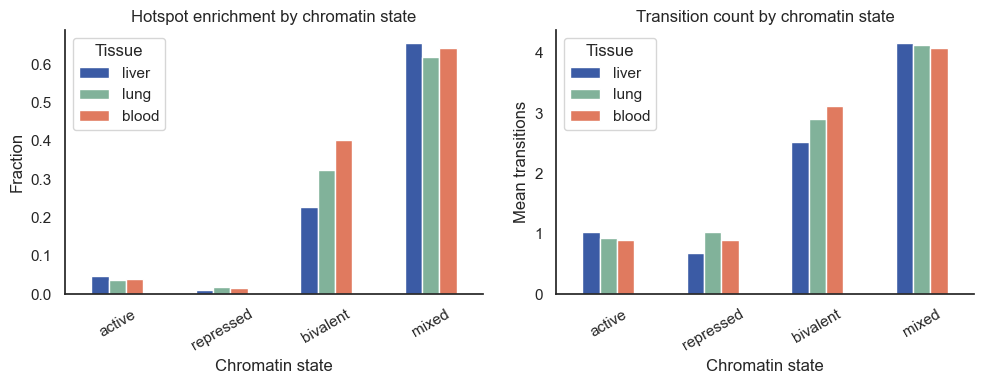

(               liver      lung     blood
 cat_normal                              
 active      0.048224  0.037544  0.037879
 repressed   0.009272  0.018709  0.015245
 bivalent    0.227957  0.323810  0.403418
 mixed       0.655556  0.618705  0.643333,
                liver      lung     blood
 cat_normal                              
 active      1.021844  0.935968  0.901716
 repressed   0.681910  1.033865  0.887872
 bivalent    2.526882  2.901587  3.115156
 mixed       4.161111  4.122302  4.083333)

In [137]:
print("NORMAL CELLS")
summary_dict = {
    "liver": (
        df_merged_liver.groupby("cat_normal")["is_hotspot_normal"].mean(),
        df_merged_liver.groupby("cat_normal")["n_trans_normal"].mean()
    ),
    "lung": (
        df_merged_lung.groupby("cat_normal")["is_hotspot_normal"].mean(),
        df_merged_lung.groupby("cat_normal")["n_trans_normal"].mean()
    ),
    "blood": (
        df_merged_blood.groupby("cat_normal")["is_hotspot_normal"].mean(),
        df_merged_blood.groupby("cat_normal")["n_trans_normal"].mean()
    )
}

plot_hotspot_and_transition_summary(summary_dict)

In [53]:
def plot_transition_heatmap_by_row_with_counts(
    df,
    transition_col="cat_transition",
    order=("active", "repressed", "bivalent", "mixed"),
    figsize=(6, 5),
    cmap="Blues",
    title="Chromatin state transitions within each normal-state group"
):
    """
    Row-normalized heatmap with BOTH percentage and absolute counts.
    """

    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    df_tmp = df.copy()
    df_tmp[["normal", "cancer"]] = df_tmp[transition_col].str.split(" -> ", expand=True)

    # absolute counts
    count_mat = pd.crosstab(df_tmp["normal"], df_tmp["cancer"])
    count_mat = count_mat.reindex(index=order, columns=order).fillna(0)

    # row-normalized (%)
    frac_mat = pd.crosstab(df_tmp["normal"], df_tmp["cancer"], normalize="index")
    frac_mat = frac_mat.reindex(index=order, columns=order).fillna(0)

    pct_mat = frac_mat * 100

    # build annotation labels
    annot = pct_mat.copy().astype(str)

    for i in pct_mat.index:
        for j in pct_mat.columns:
            pct = pct_mat.loc[i, j]
            cnt = int(count_mat.loc[i, j])
            annot.loc[i, j] = f"{pct:.1f}%\n({cnt})"

    # plot
    plt.figure(figsize=figsize)
    sns.heatmap(
        pct_mat,
        annot=annot,
        fmt="",
        cmap=cmap,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "% within normal-state group"}
    )

    plt.title(title)
    plt.xlabel("Cancer")
    plt.ylabel("Normal")

    plt.tight_layout()
    plt.show()

    return pct_mat, count_mat


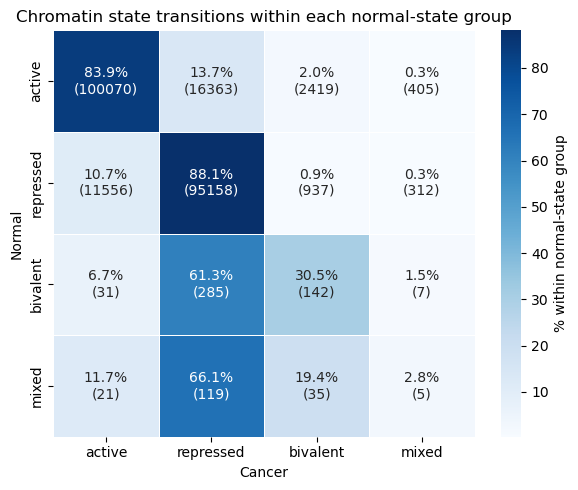

In [54]:
mat_row_pct_liver = plot_transition_heatmap_by_row_with_counts(df_merged_liver)

### Pattern A: hotspot resolves + category becomes active/repressed

In [75]:
pattern_A_liver = df_merged_liver[
    df_merged_liver["cat_normal"].isin(["bivalent", "mixed"]) &
    (df_merged_liver["is_hotspot_normal"] == True) &
    df_merged_liver["cat_cancer"].isin(["active", "repressed"]) &
    (df_merged_liver["is_hotspot_cancer"] == False)
].copy()

In [69]:
pattern_A_lung = df_merged_lung[
    df_merged_lung["cat_normal"].isin(["bivalent", "mixed"]) &
    (df_merged_lung["is_hotspot_normal"] == True) &
    df_merged_lung["cat_cancer"].isin(["active", "repressed"]) &
    (df_merged_lung["is_hotspot_cancer"] == False)
].copy()

In [73]:
pattern_A_blood = df_merged_blood[
    df_merged_blood["cat_normal"].isin(["bivalent", "mixed"]) &
    (df_merged_blood["is_hotspot_normal"] == True) &
    df_merged_blood["cat_cancer"].isin(["active", "repressed"]) &
    (df_merged_blood["is_hotspot_cancer"] == False)
].copy()

In [76]:
import pandas as pd

def make_patternA_transition_df(pattern_A_dict):
    """
    pattern_A_dict = {
        "liver": pattern_A_liver,
        "lung": pattern_A_lung,
        "blood": pattern_A_blood
    }
    """

    dfs = []

    for tissue, df in pattern_A_dict.items():
        temp = pd.DataFrame({
            "tissue": tissue,
            "normal": df["n_trans_normal"],
            "cancer": df["n_trans_cancer"]
        })

        temp_long = temp.melt(
            id_vars="tissue",
            value_vars=["normal", "cancer"],
            var_name="condition",
            value_name="n_trans"
        )

        dfs.append(temp_long)

    return pd.concat(dfs, ignore_index=True)

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_patternA_transition_violin(df_long, figsize=(5,4)):

    sns.set(style="white")  # cleaner background

    palette = {
        "normal": "cornflowerblue",   # soft blue
        "cancer": "coral"    # soft orange
    }

    plt.figure(figsize=figsize)

    sns.violinplot(
    data=df_long,
    x="tissue",
    y="n_trans",
    hue="condition",
    split=True,
    palette=palette,
    linewidth=1,
    alpha=0.6,
    cut=0
    )

    sns.stripplot(
        data=df_long,
        x="tissue",
        y="n_trans",
        hue="condition",
        dodge=True,
        palette=palette,
        size=3,
        linewidth=0
    )

    # fix legend duplication
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
    title="condition",
    bbox_to_anchor=(1.05, 1),  # 👉 move outside right
    loc="upper left",
    borderaxespad=0.
    )

    plt.ylabel("Number of transitions")
    plt.xlabel("")
    plt.title("Transition collapse in Pattern A loci", fontsize=12)


    sns.despine()  # remove top/right borders

    plt.tight_layout()
    plt.show()

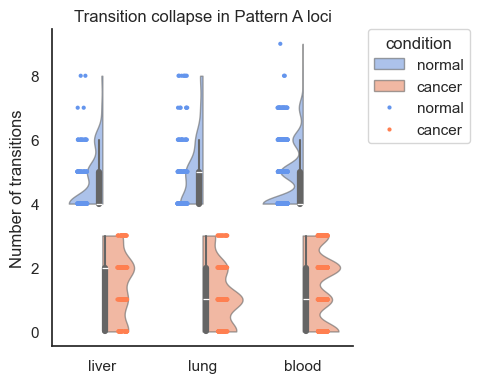

In [129]:
pattern_A_dict = {
    "liver": pattern_A_liver,
    "lung": pattern_A_lung,
    "blood": pattern_A_blood
}

df_long = make_patternA_transition_df(pattern_A_dict)

plot_patternA_transition_violin(df_long)

In [89]:
from scipy.stats import wilcoxon

for tissue, df in pattern_A_dict.items():
    stat, p = wilcoxon(df["n_trans_normal"], df["n_trans_cancer"])
    print(tissue, "p =", p)

liver p = 3.2486419268551274e-23
lung p = 1.1798782562267107e-25
blood p = 3.159005254717204e-101


### Pattern A-1: Split resolved hotspots into active vs repressed outcomes

### Pattern B: newly appeared hotspot in cancer cell

**Are there more hotspots in cancer overall?**

In [140]:
print("=== Global hotspot fraction ===")

print("Liver:",
      df_merged_liver["is_hotspot_normal"].mean(),
      "→",
      df_merged_liver["is_hotspot_cancer"].mean())

print("Lung:",
      df_merged_lung["is_hotspot_normal"].mean(),
      "→",
      df_merged_lung["is_hotspot_cancer"].mean())

print("Blood:",
      df_merged_blood["is_hotspot_normal"].mean(),
      "→",
      df_merged_blood["is_hotspot_cancer"].mean())

=== Global hotspot fraction ===
Liver: 0.030614618304697958 → 0.04234963684637834
Lung: 0.03165355743637288 → 0.03807159733229656
Blood: 0.03349467939625618 → 0.03899655894007722


CANCER CELLS


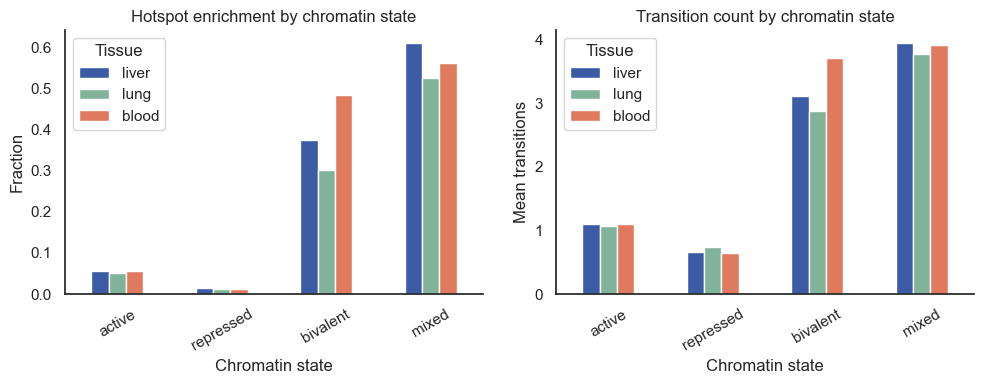

(               liver      lung     blood
 cat_cancer                              
 active      0.056672  0.051571  0.055144
 repressed   0.013866  0.012948  0.012054
 bivalent    0.374469  0.302469  0.483871
 mixed       0.611797  0.525926  0.563218,
                liver      lung     blood
 cat_cancer                              
 active      1.102017  1.076834  1.103667
 repressed   0.662497  0.732067  0.650391
 bivalent    3.110671  2.876543  3.709677
 mixed       3.951989  3.777778  3.919540)

In [139]:
print("CANCER CELLS")
summary_dict = {
    "liver": (
        df_merged_liver.groupby("cat_cancer")["is_hotspot_cancer"].mean(),
        df_merged_liver.groupby("cat_cancer")["n_trans_cancer"].mean()
    ),
    "lung": (
        df_merged_lung.groupby("cat_cancer")["is_hotspot_cancer"].mean(),
        df_merged_lung.groupby("cat_cancer")["n_trans_cancer"].mean()
    ),
    "blood": (
        df_merged_blood.groupby("cat_cancer")["is_hotspot_cancer"].mean(),
        df_merged_blood.groupby("cat_cancer")["n_trans_cancer"].mean()
    )
}

plot_hotspot_and_transition_summary(summary_dict)

In [162]:
def plot_hotspot_summary_with_overall(df_dict, figsize=(14, 10)):
    """
    Plot hotspot summary across tissues:
      Row 1: overall hotspot count and fraction (normal vs cancer)
      Row 2: hotspot counts by chromatin state
      Row 3: hotspot fractions by chromatin state

    Parameters
    ----------
    df_dict : dict
        {
            "liver": df_merged_liver,
            "lung": df_merged_lung,
            "blood": df_merged_blood
        }

    figsize : tuple
        Figure size

    Returns
    -------
    overall_df : pd.DataFrame
    count_df : pd.DataFrame
    frac_df : pd.DataFrame
    """

    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set(style="white")

    state_order = ["active", "repressed", "bivalent", "mixed"]

    overall_rows = []
    count_rows = []
    frac_rows = []

    for tissue, df in df_dict.items():
        # -------------------------
        # overall count + fraction
        # -------------------------
        n_total = len(df)

        n_hotspot_normal = int(df["is_hotspot_normal"].sum())
        n_hotspot_cancer = int(df["is_hotspot_cancer"].sum())

        overall_rows.append({
            "tissue": tissue,
            "condition": "normal",
            "count": n_hotspot_normal,
            "fraction": n_hotspot_normal / n_total
        })
        overall_rows.append({
            "tissue": tissue,
            "condition": "cancer",
            "count": n_hotspot_cancer,
            "fraction": n_hotspot_cancer / n_total
        })

        # -------------------------
        # counts by state
        # -------------------------
        normal_count = (
            df[df["is_hotspot_normal"]]
            .groupby("cat_normal")
            .size()
            .reindex(state_order, fill_value=0)
        )

        cancer_count = (
            df[df["is_hotspot_cancer"]]
            .groupby("cat_cancer")
            .size()
            .reindex(state_order, fill_value=0)
        )

        for state in state_order:
            count_rows.append({
                "tissue": tissue,
                "condition": "normal",
                "state": state,
                "count": int(normal_count[state])
            })
            count_rows.append({
                "tissue": tissue,
                "condition": "cancer",
                "state": state,
                "count": int(cancer_count[state])
            })

        # -------------------------
        # fraction by state
        # -------------------------
        normal_frac = (
            df.groupby("cat_normal")["is_hotspot_normal"]
            .mean()
            .reindex(state_order)
        )

        cancer_frac = (
            df.groupby("cat_cancer")["is_hotspot_cancer"]
            .mean()
            .reindex(state_order)
        )

        for state in state_order:
            frac_rows.append({
                "tissue": tissue,
                "condition": "normal",
                "state": state,
                "fraction": normal_frac[state]
            })
            frac_rows.append({
                "tissue": tissue,
                "condition": "cancer",
                "state": state,
                "fraction": cancer_frac[state]
            })

    overall_df = pd.DataFrame(overall_rows)
    count_df = pd.DataFrame(count_rows)
    frac_df = pd.DataFrame(frac_rows)

    # -------------------------
    # plotting
    # -------------------------
    fig, axes = plt.subplots(3, len(df_dict), figsize=figsize, squeeze=False)

    tissues = list(df_dict.keys())
    palette = {"normal": "cornflowerblue", "cancer": "coral"}

    for i, tissue in enumerate(tissues):
        # Row 1A: overall count
        ax = axes[0, i]
        sub = overall_df[overall_df["tissue"] == tissue]
        sns.barplot(
            data=sub,
            x="condition",
            y="count",
            hue="condition",
            palette=palette,
            ax=ax,
            legend=False
        )
        ax.set_title(tissue)
        ax.set_xlabel("")
        ax.set_ylabel("Overall hotspot count")
        sns.despine(ax=ax)

        # add labels
        for p in ax.patches:
            h = p.get_height()
            ax.annotate(f"{int(h)}",
                        (p.get_x() + p.get_width()/2., h),
                        ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                        textcoords='offset points')

        # # Row 2: counts by state
        # ax = axes[1, i]
        # sub = count_df[count_df["tissue"] == tissue]
        # sub["count"] = sub["count"] + 1 # prevent log(0) issues
        # sns.barplot(
        #     data=sub,
        #     x="state",
        #     y="count",
        #     hue="condition",
        #     order=state_order,
        #     palette=palette,
        #     ax=ax
        # )
        # ax.set_xlabel("")
        # ax.set_yscale("log")
        # ax.set_ylabel("Hotspot count (log scale)")
        # ax.grid(True, axis="y", linestyle="--", alpha=0.3)
        # ax.tick_params(axis="x", rotation=30)
        # sns.despine(ax=ax)
        # if i > 0:
        #     ax.get_legend().remove()
        # else:
        #     ax.legend(title="condition", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        # Row 2: counts by state
        ax = axes[1, i]
        sub = count_df[count_df["tissue"] == tissue]

        sns.barplot(
            data=sub,
            x="state",
            y="count",
            hue="condition",
            order=state_order,
            palette=palette,
            ax=ax
        )

        ax.set_yscale("log")  # 🔥 key line
        ax.set_ylabel("Hotspot count (log scale)")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)
        ax.grid(True, axis="y", linestyle="--", alpha=0.3)

        sns.despine(ax=ax)

        if i > 0:
            ax.get_legend().remove()
        else:
            ax.legend(title="condition", frameon=False,
                    bbox_to_anchor=(1.02, 1), loc="upper left")

        # Row 3: fractions by state
        ax = axes[2, i]
        sub = frac_df[frac_df["tissue"] == tissue]
        sns.barplot(
            data=sub,
            x="state",
            y="fraction",
            hue="condition",
            order=state_order,
            palette=palette,
            ax=ax,
            legend=False
        )
        ax.set_xlabel("Chromatin state")
        ax.set_ylabel("Hotspot fraction")
        ax.tick_params(axis="x", rotation=30)
        sns.despine(ax=ax)

        # add fraction labels
        for p in ax.patches:
            h = p.get_height()
            ax.annotate(f"{h:.2f}",
                        (p.get_x() + p.get_width()/2., h),
                        ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                        textcoords='offset points')

    plt.tight_layout()
    plt.show()

    return overall_df, count_df, frac_df

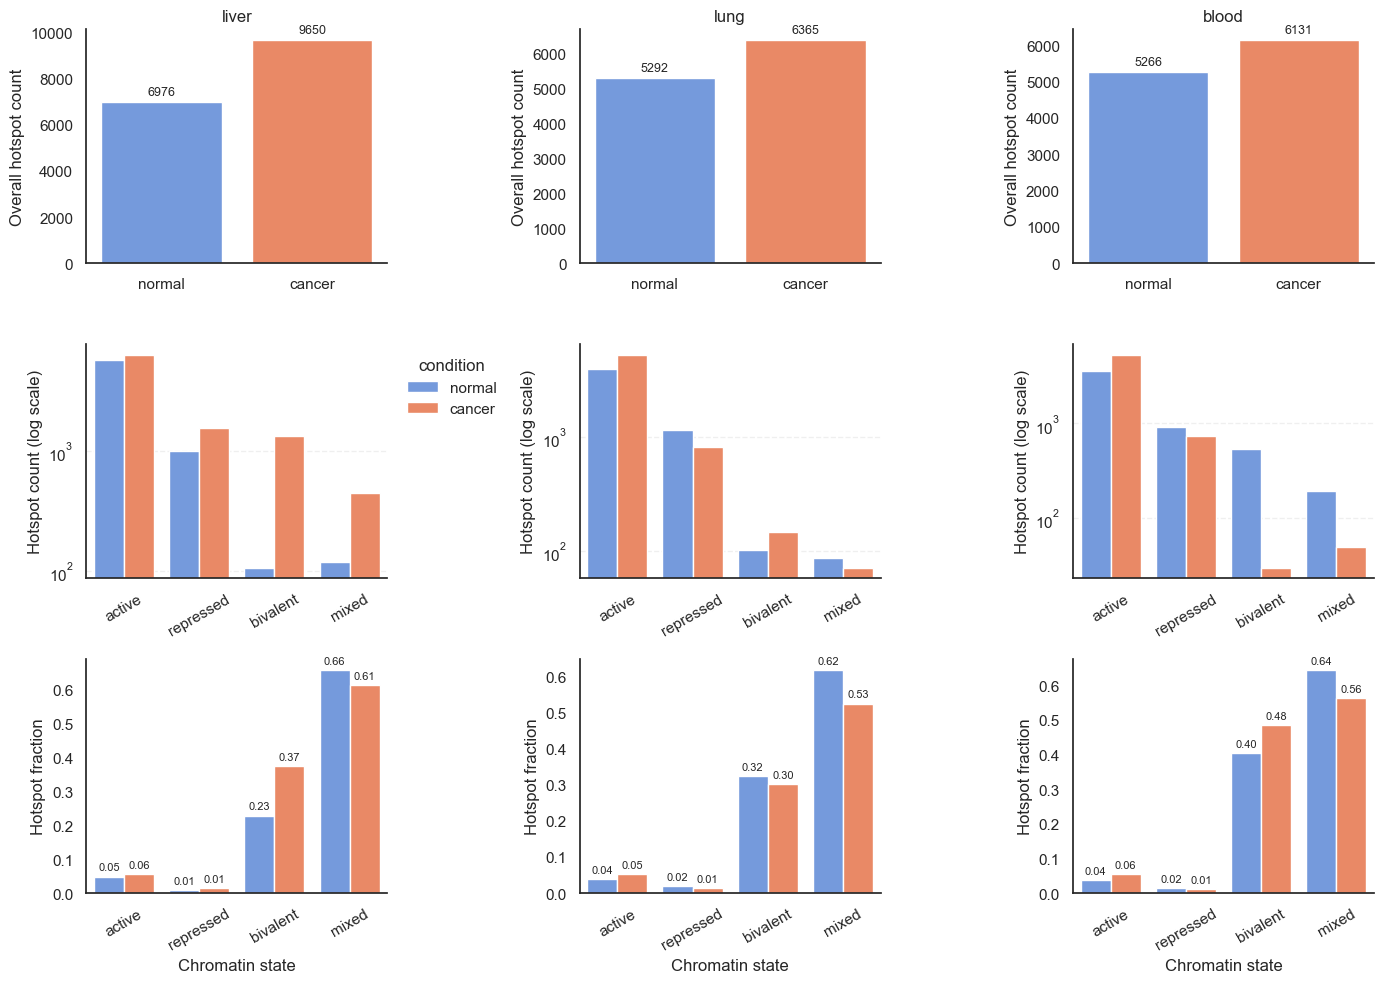

In [163]:
df_dict = {
    "liver": df_merged_liver,
    "lung": df_merged_lung,
    "blood": df_merged_blood
}

overall_df, count_df, frac_df = plot_hotspot_summary_with_overall(df_dict)